In [1]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
import category_encoders as ce

In [24]:
filepath = "../Train/task4/introml_2024_task4_train.csv"
df = pd.read_csv(filepath)
df

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,class
0,f01,f11,f21,?,f41,f51,f61,f71,0.2261,1.0092,0.9735,0.5856,1.5732,4.7563,0.808,0.8188,f160,f170,f181,C0
1,f01,f10,f20,f30,f40,?,f61,f71,0.3586,0.0673,0.8581,0.5175,3.227,4.1908,0.2499,2.9982,f161,f170,f181,C0
2,f01,f10,f21,f31,f40,f50,?,f71,0.9501,1.1015,0.0511,0.3113,1.213,5.0398,0.6183,4.267,f161,f171,f181,C0
3,f01,?,f20,f30,f41,f50,f60,f71,0.8244,0.4243,0.8692,0.6662,1.2181,4.7104,0.3333,2.9876,f161,f170,f180,C0
4,f01,f11,f21,f31,f41,f50,f61,f71,1.1654,0.2593,0.1525,0.8781,2.2129,1.5904,0.3565,1.0673,f160,f170,f180,C0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,f01,f11,f20,f31,f40,f50,f61,f71,0.2228,0.7997,0.2169,1.0913,2.5216,2.6287,0.7894,1.4817,f161,f170,f180,C5
4796,?,f10,f20,f30,f40,f51,f61,f71,0.131,0.3242,0.1186,0.1703,1.7939,0.6713,?,4.6415,f161,f170,f181,C5
4797,f01,f10,f20,f30,f40,f51,f60,f71,0.4483,1.6061,0.3918,1.2872,1.1864,0.1411,0.1469,5.3212,f161,f171,f181,C5
4798,f00,f10,f20,f30,f41,f51,f60,f71,0.4568,0.9159,0.8263,0.5226,1.6286,3.2508,0.0649,1.299,f160,f170,f180,C5


In [25]:
# 前處理
cols = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7','f16', 'f17', 'f18', 'class'] # 0/1變數, class 分類

for c in cols:
    df[c] = df[c].apply(lambda x: x if x=='?' else int(x[-1]))

df.replace("?", np.nan, inplace=True)
df.dropna()

/var/folders/z8/tkcn56l93cb258d6cngvzl1h0000gn/T/ipykernel_88705/3384381352.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("?", np.nan, inplace=True)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,class
4,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.1654,0.2593,0.1525,0.8781,2.2129,1.5904,0.3565,1.0673,0,0,0,0
6,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.442,0.1757,1.1278,1.1412,2.9876,4.6028,1.015,7.6795,1,0,0,0
7,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.5492,0.943,0.3999,0.3875,1.3939,5.3064,0.1103,2.2709,1,0,1,0
8,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.3173,0.8124,1.1043,0.8776,0.551,1.8266,0.1027,1.013,1,1,1,0
9,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.71,0.3074,0.4906,0.4639,2.7333,3.8622,0.2828,1.1788,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4789,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.9738,0.2162,1.3014,0.2948,1.5581,1.8104,0.6952,2.1777,1,0,0,5
4791,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.1043,0.4371,1.0625,0.0947,2.3004,3.0557,0.4393,5.3411,1,1,1,5
4795,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.2228,0.7997,0.2169,1.0913,2.5216,2.6287,0.7894,1.4817,1,0,0,5
4797,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.4483,1.6061,0.3918,1.2872,1.1864,0.1411,0.1469,5.3212,1,1,1,5


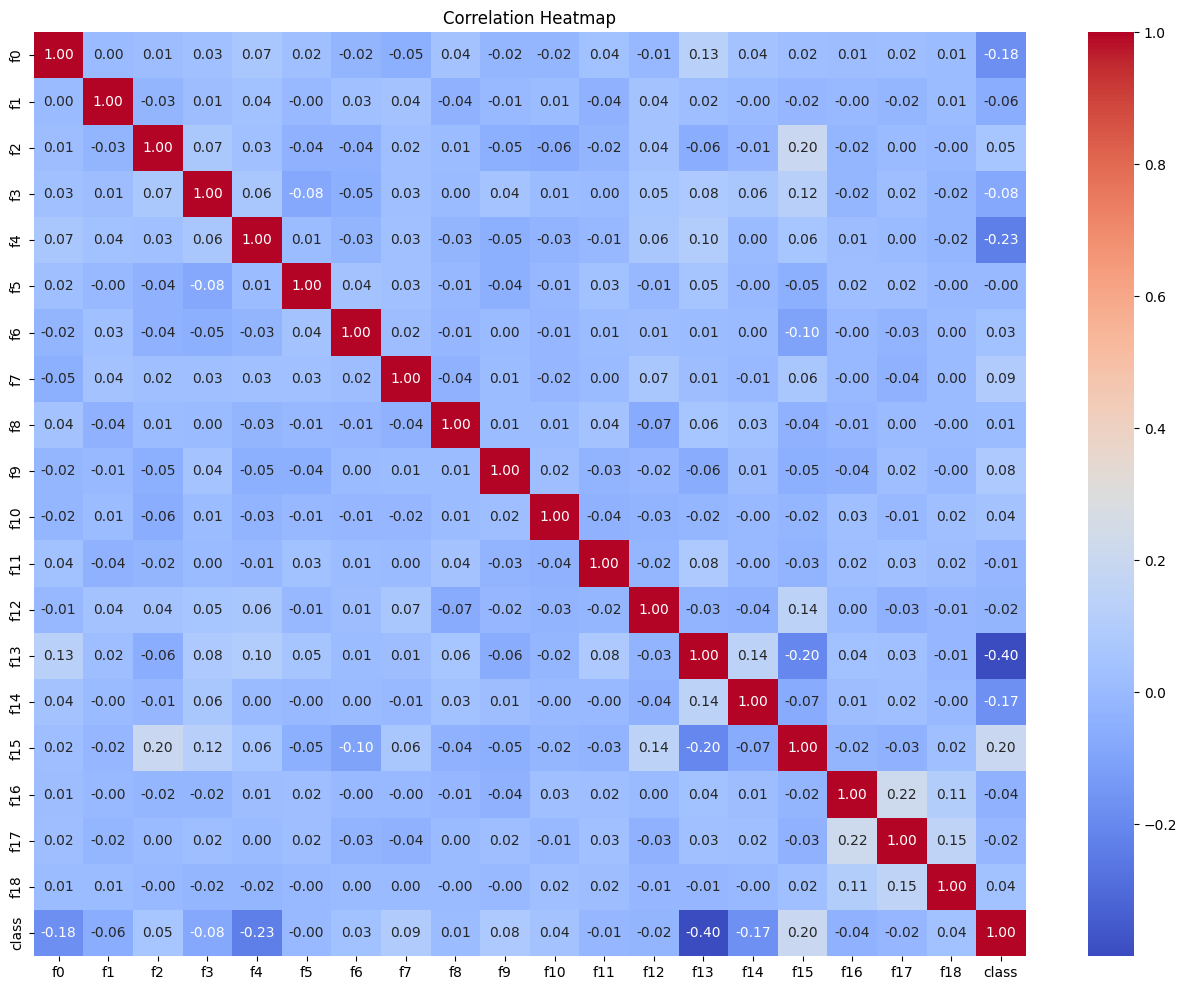

In [20]:
# 计算相关性矩阵
correlation_matrix = df.corr()
plt.figure(figsize=(16, 12))
# 创建热图
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
from sklearn.impute import KNNImputer
col1 = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f16', 'f17', 'f18']
col2 = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']
imputer = KNNImputer(n_neighbors=5)
df_imputed_col2 = imputer.fit_transform(df[col2])
df_imputed_col2

df_imputed_col1 = imputer.fit_transform(df[col1])
df_imputed_col1.round()
df_imputed1 = pd.DataFrame(df_imputed_col1.round(), columns=col1)

# 眾數 .779
# df_imputed_col1 = df[col1]
# for class_ in range(6):
#     for c in col1:
#         most_frequent_value = df_imputed_col1[c].mode()[0]
#         df_imputed_col1[c].fillna(most_frequent_value, inplace=True)
# df_imputed1 = df_imputed_col1


df_imputed2 = pd.DataFrame(df_imputed_col2, columns=col2)

df2=pd.concat([df_imputed1, df_imputed2, df.iloc[:,-1]], axis=1)
df2.dropna()

,f0,f1,f2,f3,f4,f5,f6,f7,f16,f17,f18,f8,f9,f10,f11,f12,f13,f14,f15,class
0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.2261,1.0092,0.9735,0.5856,1.5732,4.7563,0.80800,0.81880,0
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.3586,0.0673,0.8581,0.5175,3.2270,4.1908,0.24990,2.99820,0
2,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.9501,1.1015,0.0511,0.3113,1.2130,5.0398,0.61830,4.26700,0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.8244,0.4243,0.8692,0.6662,1.2181,4.7104,0.33330,2.98760,0
4,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.1654,0.2593,0.1525,0.8781,2.2129,1.5904,0.35650,1.06730,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.2228,0.7997,0.2169,1.0913,2.5216,2.6287,0.78940,1.48170,5
4796,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.1310,0.3242,0.1186,0.1703,1.7939,0.6713,0.58988,4.64150,5
4797,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.4483,1.6061,0.3918,1.2872,1.1864,0.1411,0.14690,5.32120,5
4798,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.4568,0.9159,0.8263,0.5226,1.6286,3.2508,0.06490,1.29900,5


In [ ]:
X =df2.iloc[:, :-1]
y = df2.iloc[:, -1] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


# # 5. 模型预测
y_pred = model.predict(X_test)

# print(y_pred)

# # 6. 性能评估
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

print(model.feature_importances_)

Accuracy: 0.7541666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.68      0.74       141
           1       0.90      0.80      0.84       183
           2       0.66      0.89      0.76       149
           3       0.73      0.69      0.71       167
           4       0.72      0.71      0.72       153
           5       0.75      0.75      0.75       167

    accuracy                           0.75       960
   macro avg       0.76      0.75      0.75       960
weighted avg       0.76      0.75      0.75       960

[0.01184328 0.01113487 0.01668718 0.02600434 0.01949943 0.01680758
 0.01347333 0.01795816 0.01059837 0.01054226 0.01011553 0.07812371
 0.07767075 0.05951233 0.069622   0.09084259 0.17189193 0.08099001
 0.20668235]


In [37]:
ansfile = "../Train/task4/introml_2024_task4_test_NO_answers_shuffled.csv"
ans = pd.read_csv(ansfile)

# 前處理
cols = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7','f16', 'f17', 'f18'] # 0/1變數, class 分類

for c in cols:
    ans[c] = ans[c].apply(lambda x: x if x=='?' else int(x[-1]))

ans.replace("?", np.nan, inplace=True)

from sklearn.impute import KNNImputer
col1 = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f16', 'f17', 'f18']
col2 = ['f8', 'f9', 'f10','f11', 'f12', 'f13', 'f14', 'f15']
imputer = KNNImputer(n_neighbors=5)
df_imputed_col2 = imputer.fit_transform(ans[col2])
df_imputed_col2

df_imputed_col1 = imputer.fit_transform(ans[col1])
df_imputed_col1.round()
df_imputed1 = pd.DataFrame(df_imputed_col1.round(), columns=col1)

# 眾數 .779
# df_imputed_col1 = df[col1]
# for class_ in range(6):
#     for c in col1:
#         most_frequent_value = df_imputed_col1[c].mode()[0]
#         df_imputed_col1[c].fillna(most_frequent_value, inplace=True)
# df_imputed1 = df_imputed_col1


df_imputed2 = pd.DataFrame(df_imputed_col2, columns=col2)

ans2=pd.concat([df_imputed1, df_imputed2], axis=1)
ans2.dropna()


ans_pred = model.predict(ans2)



trans = np.vectorize(lambda x : "C"+str(x))
ans_pred = trans(ans_pred)
submit = pd.DataFrame({
    "id" : range(0, len(ans_pred)),
    "class" : ans_pred
})

submit.to_csv('../Submit/task4/submission.csv', index=False)


/var/folders/z8/tkcn56l93cb258d6cngvzl1h0000gn/T/ipykernel_88705/746767143.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ans.replace("?", np.nan, inplace=True)


In [38]:
# Submition : 3 per day
input() # 避免誤點到
!kaggle competitions submit -c introml-nccu-2024-task-4 -f ../Submit/task4/submission.csv -m "Message"

100%|██████████████████████████████████████| 8.30k/8.30k [00:00<00:00, 10.4kB/s]
Successfully submitted to introml@nccu_2024_task4